In this project, we will use the daily returns of NVIDIA stocks for the past 5 years to conduct a time series analysis. We will check whether NVDA stock data is serially correlated, and model the time varying volatility using GARCH(1,1). Based off of the analysis, we can forecast NVDA stock prices for the next 5 days with 95% confidence and make some data-driven conclusions about the NVDA market. We then conduct a correlation analysis between NVIDIA and other tech companies before and after the AI boom.

Start by importing all the relevant libraries.

In [253]:
import yfinance as yf
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

The first thing we want to do is fetch NVDA stock data. For this case, we don't need an API because we can download the data directly from the yfinance module. I have chosen to include daily stock returns over the past 5 years.

In [149]:
# Calculate date range (5 years from today)
end_date = datetime.now()
start_date = end_date - timedelta(days=5*365)

# Format dates
start_str = start_date.strftime('%Y-%m-%d')
end_str = end_date.strftime('%Y-%m-%d')

nvda = yf.download('NVDA', start=start_str, end=end_str, auto_adjust=False)

nvda

[*********************100%***********************]  1 of 1 completed


Price,Adj Close,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,,
2020-11-18,13.387882,13.428750,13.605750,13.185000,13.465250,510924000
2020-11-19,13.399349,13.440250,13.487500,13.100000,13.212750,565936000
2020-11-20,13.047920,13.087750,13.494500,13.065000,13.454000,341088000
2020-11-23,13.100011,13.140000,13.382500,13.015500,13.171250,361356000
2020-11-24,12.918315,12.957750,13.162000,12.885000,13.142500,346500000
...,...,...,...,...,...,...
2025-11-10,199.050003,199.050003,199.940002,193.789993,195.110001,198897100
2025-11-11,193.160004,193.160004,195.419998,191.300003,195.160004,176483300


We will use the Adj Close price column, which gives a good estimation of the true value of NVDA stock, to calculate the daily returns/log returns to capture NVDA stock performance. We also prepare the squared dataset, which we will use to measure volatility.

In [150]:
price_col = 'Adj Close'

# Calculate paramaters
nvda['Returns'] = nvda[price_col].pct_change()
nvda['Log_Returns'] = np.log(nvda[price_col] / nvda[price_col].shift(1))

# Remove NaN value
returns_simple = nvda['Returns'].dropna()
returns_log = nvda['Log_Returns'].dropna()

# Also look at squared returns (volatility clustering)
returns_simple_squared = returns_simple ** 2
returns_log_squared = returns_log ** 2

Next, let's visualize the data!

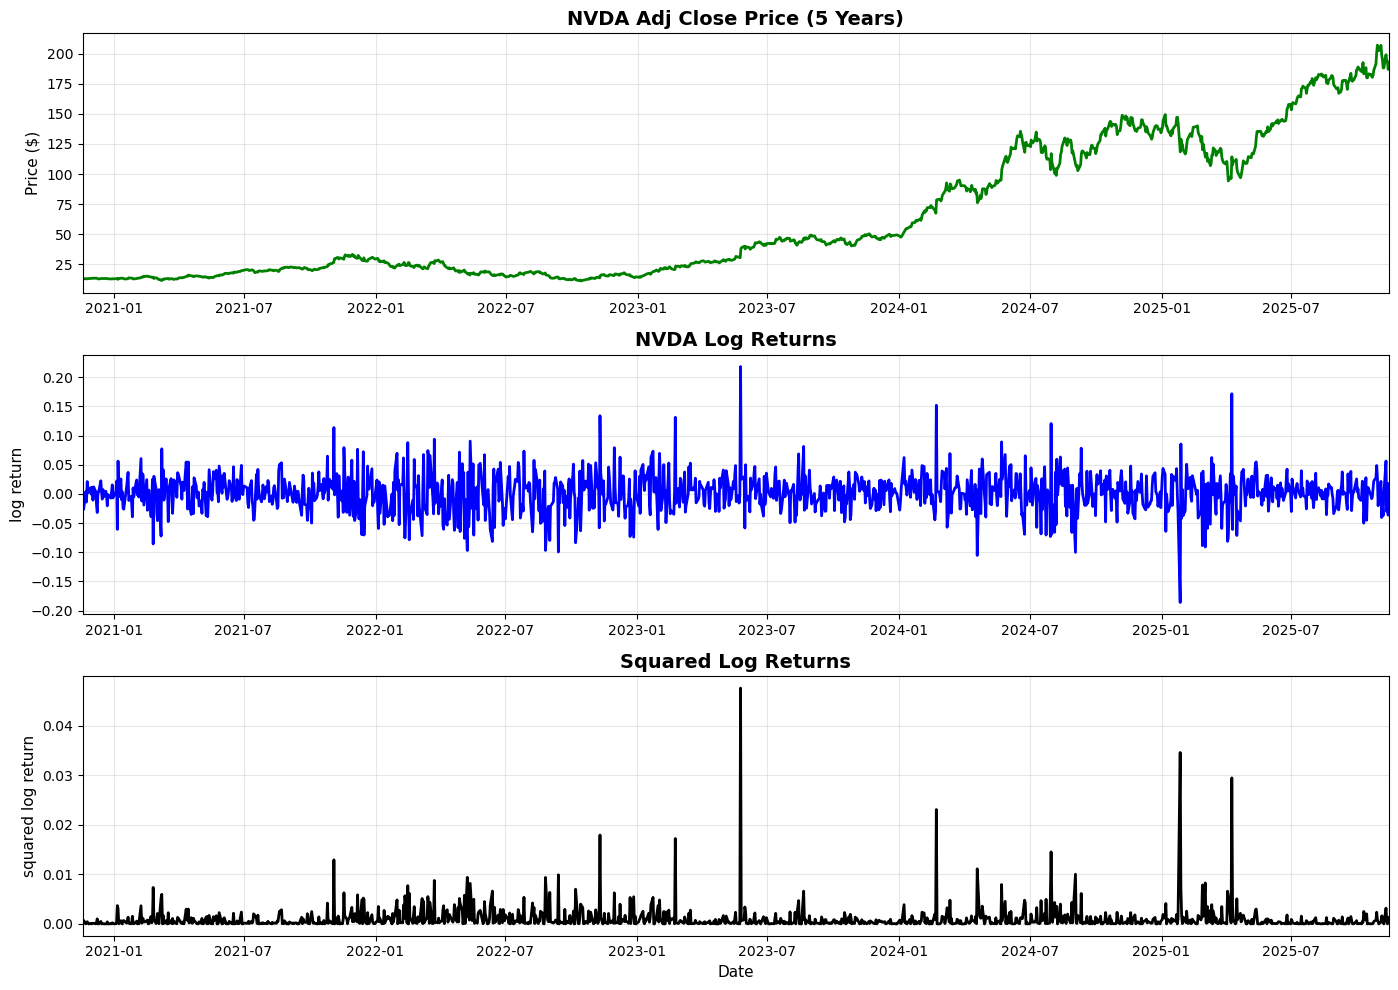

In [195]:
# Visualize the data
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

# Price chart
axes[0].plot(nvda.index, nvda[price_col], linewidth=2, color='g')
axes[0].set_title(f'NVDA {price_col} Price (5 Years)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Price ($)', fontsize=11)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(nvda.index[0], nvda.index[-1])

# Log returns (direction)
axes[1].plot(returns_log.index, returns_log, linewidth=2, color='b')
axes[1].set_title('NVDA Log Returns', fontsize=14, fontweight='bold')
axes[1].set_ylabel('log return', fontsize=11)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(returns_log.index[0], returns_log.index[-1])

# Log returns squared (magnitude)
axes[2].plot(returns_log.index, returns_log_squared, linewidth=2, color='black')
axes[2].set_title('Squared Log Returns', fontsize=14, fontweight='bold')
axes[2].set_ylabel('squared log return', fontsize=11)
axes[2].set_xlabel('Date', fontsize=11)
axes[2].grid(True, alpha=0.3)
axes[2].set_xlim(returns_log.index[0], returns_log.index[-1])

plt.tight_layout()
plt.show()

Just from a cursory glance, it's pretty clear that NVDA was pretty stable throughout COVID, until it started rapidly rising starting mid 2023. We will analyze this behavior further, but first let's start by modeling the time series of the middle plot, NVDA Log Returns.

We want to check if there is serial dependence in the data, since it could just be a white noise series. But if there is serial dependence, we can use an ARMA model to build a mean equation.

A good way to check for serial dependence is by conducting an EACF (Extended Autocorrelation Function) analysis. Unfortunately, python does not have a library to conduct this analysis, but we can do it quickly and easily in R. Here is the EACF table, obtained from R:

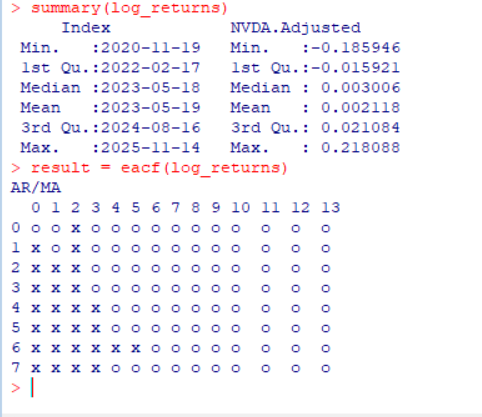

We obtain an interesting EACF table, where we really have two options from this point. Is the log return data close to a white noise series, indicated by a (0,0) model? Or are there some lag-3 correlations, and the data is best fit to an ARMA (0,3) model? For more insight, we plot the autocorrelation function (ACF) and partial autocorrelation function (PACF) for the log returns.

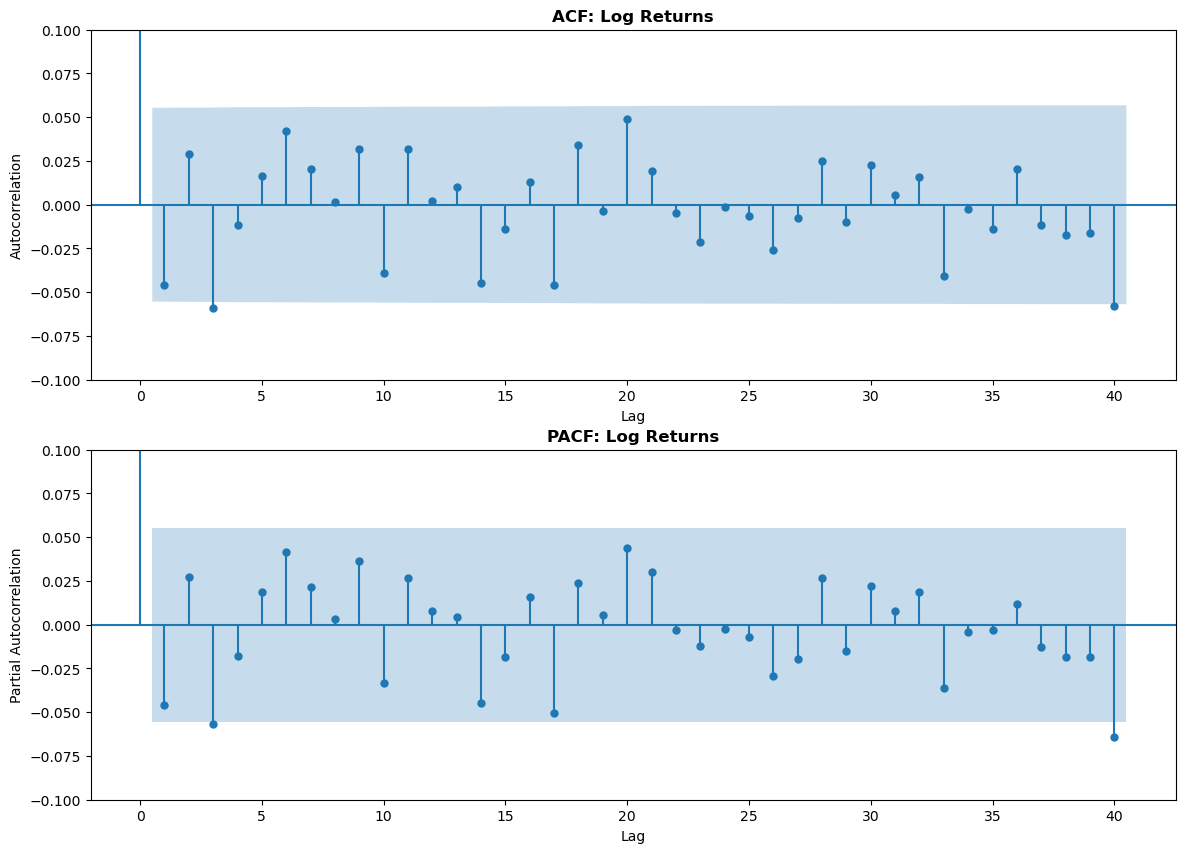


Log Returns:
      lb_stat  lb_pvalue
4    8.276521   0.081958
8   11.396617   0.180223
12  15.906542   0.195554
20  26.232977   0.158255
30  29.884993   0.471555
40  38.468209   0.539285


In [177]:
fig, axes = plt.subplots(2, figsize=(14, 10))


plot_acf(returns_log, lags=40, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF: Log Returns', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('Autocorrelation')
axes[0].set_ylim(-0.1, 0.1)

plot_pacf(returns_log, lags=40, ax=axes[1], alpha=0.05, method='ywm')
axes[1].set_title('PACF: Log Returns', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('Partial Autocorrelation')
axes[1].set_ylim(-0.1, 0.1)

plt.show()

print("\nLog Returns:")
lb_log = acorr_ljungbox(returns_log, lags=[4, 8, 12, 20, 30, 40], return_df=True)
print(lb_log)

As you can see, although there are a few statistically significant points at lag-3 and lag-40, the majority of the data is serially uncorrelated and the lag-3 AC is probably an outlier. The Ljung-Box test confirms that no significant correlations exist. For fun, we can try fitting the log returns data to an MA(3) model:

In [167]:
from statsmodels.tsa.arima.model import ARIMA

ma3_model = ARIMA(returns_log, order=(0, 0, 3))
ma3_fit = ma3_model.fit()

# View model summary
print(ma3_fit.summary())

                               SARIMAX Results                                
Dep. Variable:            Log_Returns   No. Observations:                 1253
Model:                 ARIMA(0, 0, 3)   Log Likelihood                2517.151
Date:                Mon, 17 Nov 2025   AIC                          -5024.303
Time:                        12:39:45   BIC                          -4998.636
Sample:                             0   HQIC                         -5014.655
                               - 1253                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0021      0.001      2.416      0.016       0.000       0.004
ma.L1         -0.0454      0.026     -1.753      0.080      -0.096       0.005
ma.L2          0.0278      0.026      1.063      0.2

This fit is further justification that a model is not needed: although the 3rd lag parameter is statistically significant (p=0.029), the overall model still leaves further unfitted serial correlations (Ljung-Box parameter 0.00<0.05) and is not an adequate model. This leads us down a path where we end up overfitting our data.

What kind of conclusions can we draw from this?

Well, the daily returns is close to a white noise data set, with a positive mean, $μ$, of 0.2% (see below).

In [193]:
returns_log.mean()

np.float64(0.0021177720770229383)

This means that past prices contain no information in predicting future prices, i.e. the direction of price change is unpredictable. The NVDA stock price, therefore, can be modeled by a random walk with drift:

$log(P_t) = log(P_{t-1}) + μ + a_t$

where $P_t$ is the price of the stock at time t, $μ$ is the positive mean of 0.2%, and $a_t$ is the size of the next step.

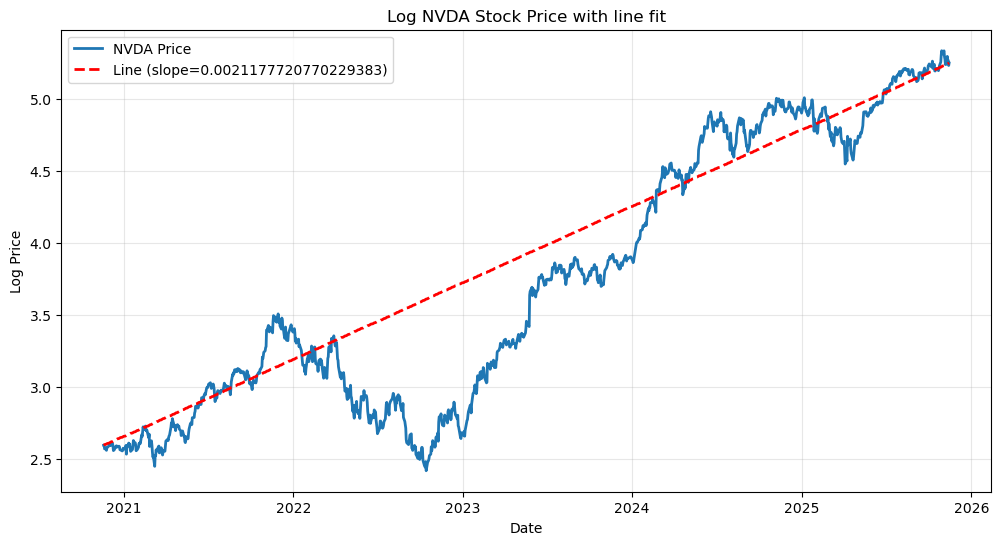

In [200]:
log_prices = np.log(nvda['Adj Close'])

x = np.arange(len(nvda))
m = returns_log.mean()
b = float(log_prices.iloc[0])  # y-intercept
line = m * x + b

# Plot
plt.figure(figsize=(12, 6))
plt.plot(nvda.index, log_prices, label='NVDA Price', linewidth=2)
plt.plot(nvda.index, line, label=f'Line (slope={m})', 
         linestyle='--', color='red', linewidth=2)
plt.title('Log NVDA Stock Price with line fit')
plt.xlabel('Date')
plt.ylabel('Log Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

By extension, the actual price of NVDA stock can be modeled by an exponential fit.

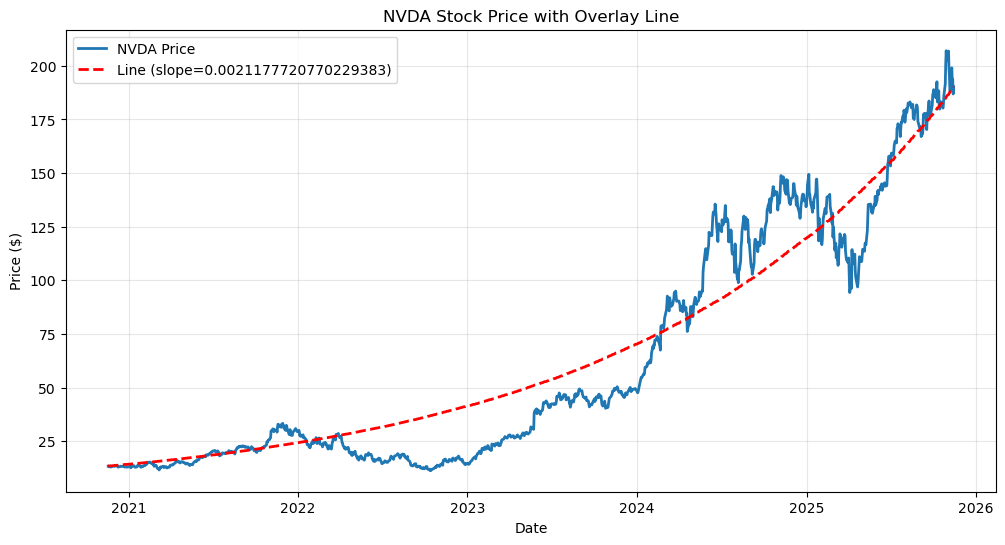

In [197]:
plt.figure(figsize=(12, 6))
plt.plot(nvda.index, nvda['Adj Close'], label='NVDA Price', linewidth=2)
plt.plot(nvda.index, np.exp(line), label=f'exponential fit', 
         linestyle='--', color='red', linewidth=2)
plt.title('NVDA Stock Price with Overlay Line')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In reality, however, we know that there is much more to this $a_t$ parameter. $a_t$ can be described as the size of each step of the random walk, but it can also be described as the shock to the system. It is heavily related to the volatility of the system, which we model from hereon.

To model the volatility of NVIDIA stock (in other words, the standard deviation) over time, first we must check that the volatility is time-varying. If the volatility is indeed not constant, then we need a conditional heteroscedastic model.

We can check the conditional heteroscedasticity two ways:
1) We conduct a Lagrange multiplier test on the log return data. We conduct an LM test for 40 lags below.

In [201]:
from statsmodels.stats.diagnostic import het_arch

arch_tests = []
for lag in range(1, 41):
    lm_stat, lm_pval, f_stat, f_pval = het_arch(returns_log, nlags=lag)
    arch_tests.append({'nlags': lag, 'LM_stat': lm_stat, 'LM_pval': lm_pval, 
                       'F_stat': f_stat, 'F_pval': f_pval})

arch_df = pd.DataFrame(arch_tests)
print(arch_df)

    nlags    LM_stat   LM_pval    F_stat    F_pval
0       1   2.669028  0.102318  2.670458  0.102478
1       2   4.166230  0.124542  2.085064  0.124732
2       3   4.717505  0.193691  1.573408  0.194044
3       4  10.588633  0.031598  2.659104  0.031451
4       5  11.555920  0.041406  2.321569  0.041213
5       6  12.453303  0.052587  2.084719  0.052351
6       7  13.384086  0.063285  1.920364  0.063005
7       8  13.318951  0.101337  1.670707  0.101111
8       9  13.372777  0.146451  1.489936  0.146365
9      10  13.709675  0.186651  1.373989  0.186726
10     11  13.865789  0.240509  1.262441  0.240867
11     12  13.969677  0.302649  1.165060  0.303384
12     13  16.271632  0.234773  1.253987  0.235017
13     14  16.286346  0.296202  1.164534  0.296866
14     15  16.220216  0.367569  1.081543  0.368760
15     16  16.201040  0.439020  1.011902  0.440745
16     17  16.154443  0.512914  0.948824  0.515163
17     18  16.663592  0.546337  0.923980  0.548852
18     19  16.630690  0.614872 

We can see that the LM and F p-value dips below 0.05 at lag-3 and lag-4, suggesting a need for GARCH modeling (volatility evolves over time).

2) We look at the ACF and PACF functions of the squared log returns, which is an indicator for how previous magnitude changes correlate to each other. We can use a Ljung-Box test to see whether the data is serially coordinated. We conduct this analysis below.

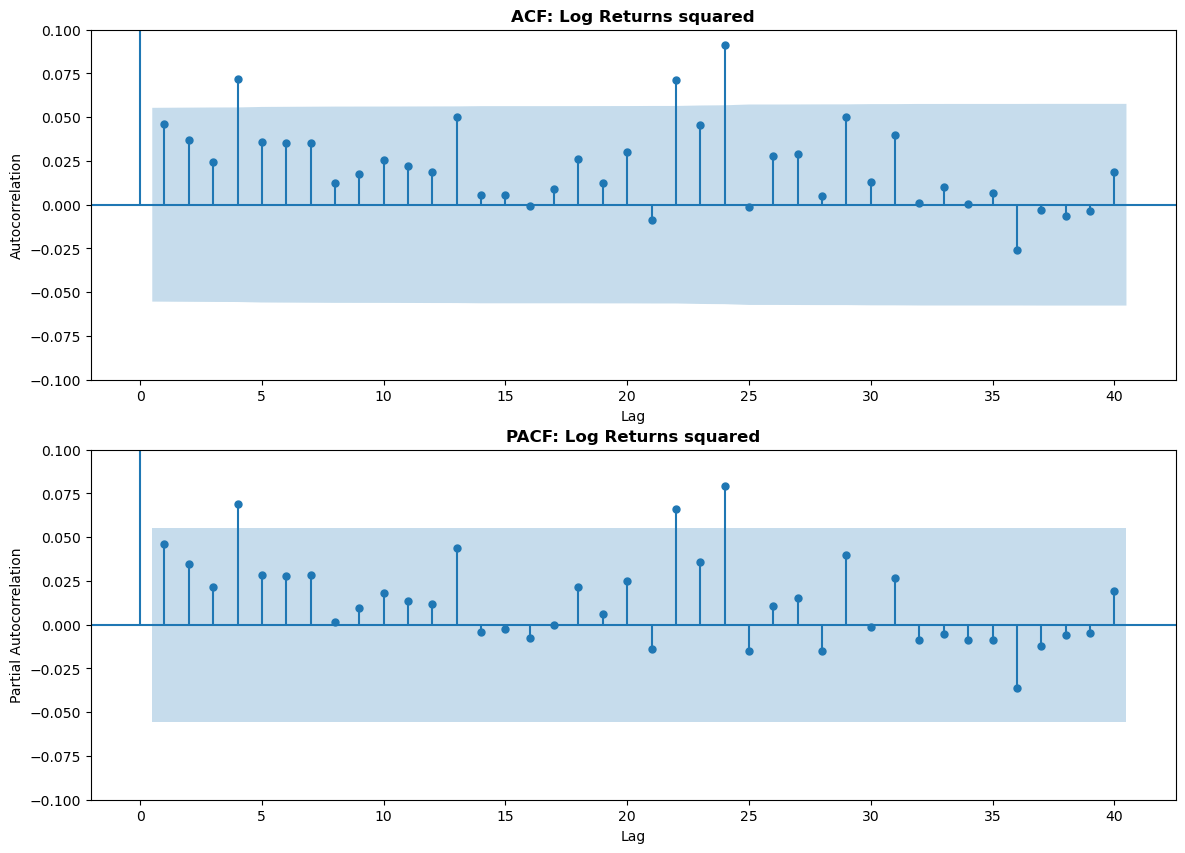


Squared Log Returns (ARCH effects):
      lb_stat  lb_pvalue
10  17.811700   0.058224
20  24.481635   0.221986
30  49.836491   0.012896
40  53.465916   0.075458


In [202]:
fig, axes = plt.subplots(2, figsize=(14, 10))

plot_acf(returns_log_squared, lags=40, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF: Log Returns squared', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Lag')
axes[0].set_ylabel('Autocorrelation')
axes[0].set_ylim(-0.1, 0.1)

plot_pacf(returns_log_squared, lags=40, ax=axes[1], alpha=0.05)
axes[1].set_title('PACF: Log Returns squared', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('Partial Autocorrelation')
axes[1].set_ylim(-0.1, 0.1)

plt.show()

print("\nSquared Log Returns (ARCH effects):")
lb_log_sq = acorr_ljungbox(returns_log_squared, lags=[10, 20, 30, 40], return_df=True)
print(lb_log_sq)

Indeed, our second test confirms the need for GARCH modeling for volatility. Interestingly, our autocorrelation functions indicate significant correlations at lag-4 and around lag-20 to lag-25, suggesting that our volatility clustering occurs on two time scales: weekly and monthly. In other words, this can be interpreted as a more positive weekly report or monthly report will generate further growth and positivity in stock price (higher shock magnitude), and similar for negative sentiments.

We model our log returns data to a GARCH(1,1) model (the most common model used) below.

In [206]:
garch11 = arch_model(returns_log, vol='Garch', p=1, q=1, mean='Constant', dist='t')
garch11_fit = garch11.fit()
print(garch11_fit.summary())

Iteration:      1,   Func. Count:      7,   Neg. LLF: 120870.37110147711
Iteration:      2,   Func. Count:     23,   Neg. LLF: 143855.06630788435
Iteration:      3,   Func. Count:     38,   Neg. LLF: 125774.31993092482
Optimization terminated successfully    (Exit mode 0)
            Current function value: -2608.1759092447483
            Iterations: 4
            Function evaluations: 46
            Gradient evaluations: 3
                        Constant Mean - GARCH Model Results                         
Dep. Variable:                  Log_Returns   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:                2608.18
Distribution:      Standardized Student's t   AIC:                          -5206.35
Method:                  Maximum Likelihood   BIC:                          -5180.69
                                              No. Observations

We can see that the GARCH model converges well, and each of the parameters are statistically significant. "mu" is the same mean as before, and the omega, alpha[1], and beta[1] parameter represent the values in the following equation:

$σ²_t = ω + α*ε²_{t-1} + β*σ²_{t-1}$

where omega is the constant term representing the baseline volatility, alpha is the impact of the shock parameter from the previous day, and beta is the persistence of the volatility from the previous day.

With this model's values, $α=0.05$ and $β=0.93$ can be interpreted as 5% of today's volatility coming from today's shock and 93% of today's volatility coming from conditional variance.

We can plot our volatility/conditional variance over time and use our volatility model to represent 95% confidence intervals on our NVIDIA stock price:

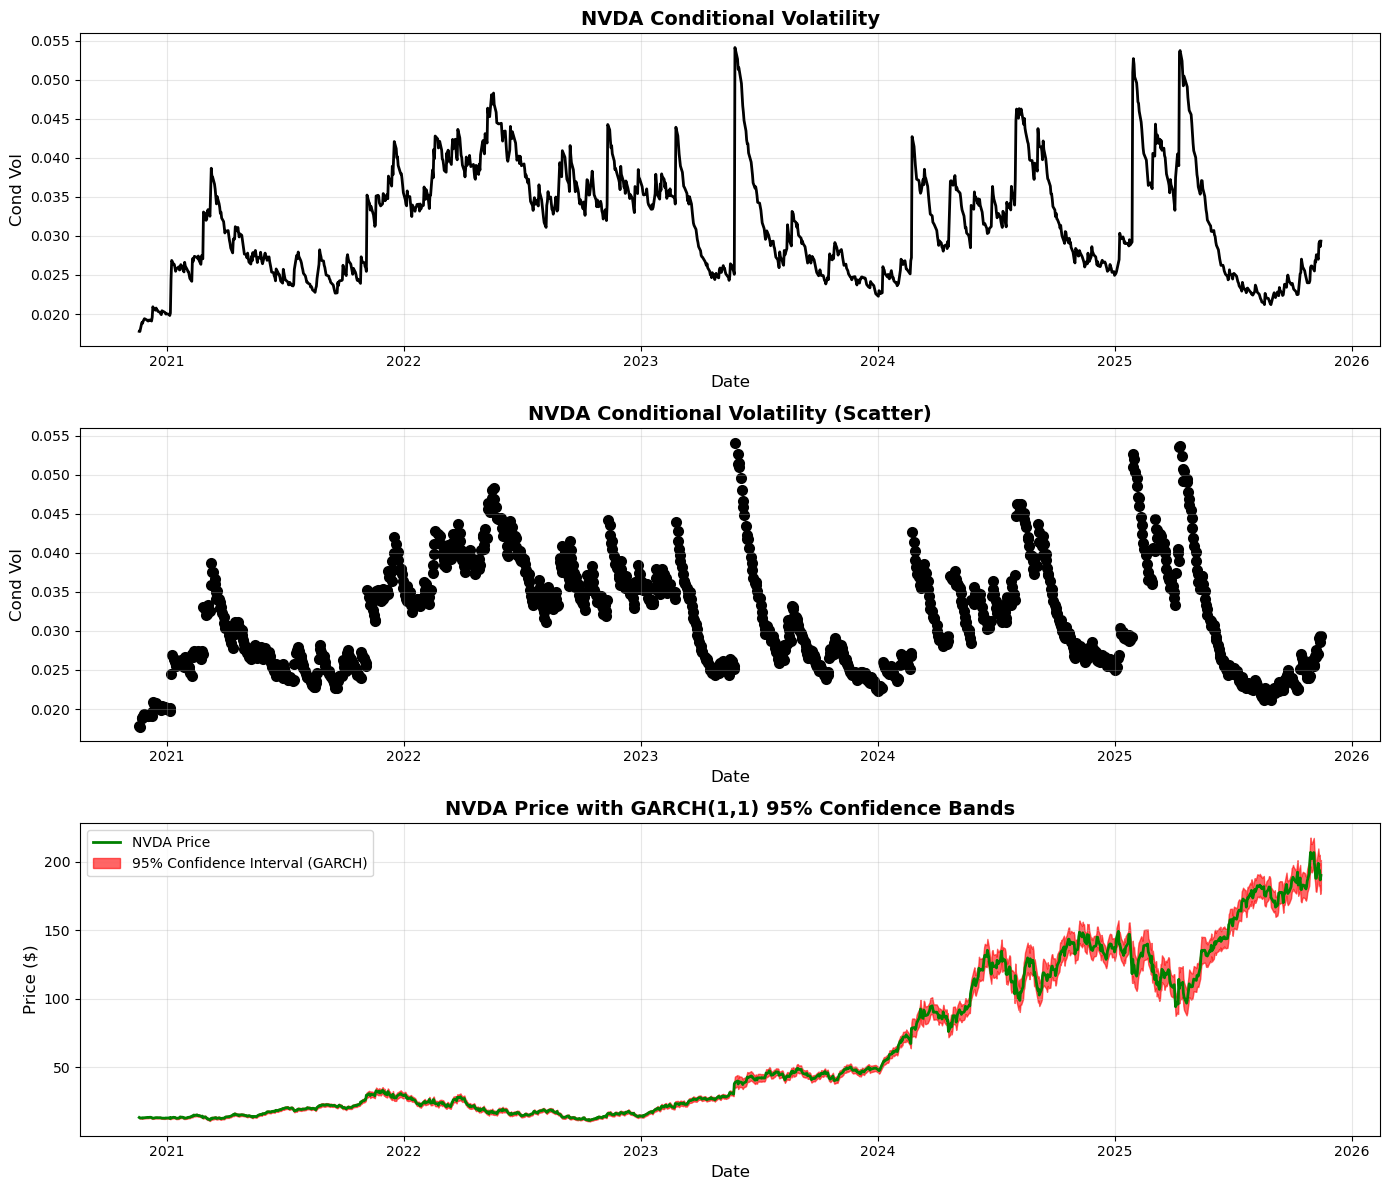

In [212]:
# Get conditional volatility from GARCH model
cond_vol = garch11_fit.conditional_volatility

# Calculate 95% confidence interval (±1.96 standard deviations)
# Convert log returns volatility to price changes
price = nvda['Adj Close'].loc[cond_vol.index]
price_arr = np.array(price).flatten()
upper_band = price_arr * np.exp(1.96 * cond_vol)  # Divide by 100 if returns are in %
lower_band = price_arr * np.exp(-1.96 * cond_vol)

# Plot
fig, axes = plt.subplots(3, figsize=(14, 12))

axes[0].plot(cond_vol.index, cond_vol, linewidth=2, color='black')
axes[0].set_title('NVDA Conditional Volatility', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Cond Vol', fontsize=12)
axes[0].set_xlabel('Date', fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].scatter(cond_vol.index, cond_vol, linewidth=2, color='black')
axes[1].set_title('NVDA Conditional Volatility (Scatter)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Cond Vol', fontsize=12)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].grid(True, alpha=0.3)

axes[2].plot(price.index, price, linewidth=2, color='green', label='NVDA Price')
axes[2].fill_between(price.index, lower_band, upper_band, alpha=0.6, color='red', 
                label='95% Confidence Interval (GARCH)')
axes[2].set_title('NVDA Price with GARCH(1,1) 95% Confidence Bands', fontsize=14, fontweight='bold')
axes[2].set_ylabel('Price ($)', fontsize=12)
axes[2].set_xlabel('Date', fontsize=12)
axes[2].legend(loc='upper left')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Using this model, we make a 5 day forecast of the stock price (from exponential) and volatility (from recursive GARCH) below.

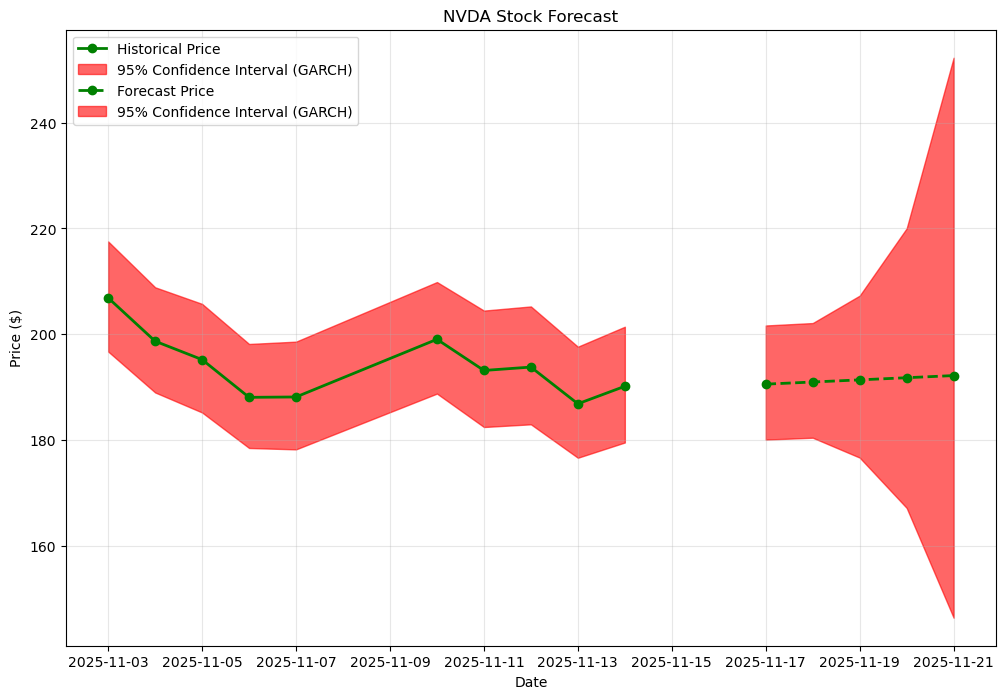

In [243]:
omega = garch11_fit.params['omega']
alpha = garch11_fit.params['alpha[1]']
beta = garch11_fit.params['beta[1]']

forecast_volatility = []
n_forecast = 5

# Get last conditional variance for GARCH
last_variance = garch11_fit.conditional_volatility.iloc[-1] ** 2
last_resid_sq = garch11_fit.resid.iloc[-1] ** 2

for i in range(n_forecast):
    # Forecast variance using GARCH(1,1)
    if i == 0:
        var_forecast = omega + alpha * last_resid_sq + beta * last_variance
    else:
        # For multi-step, use expected value E[residual²] = variance
        var_forecast = omega + (alpha + beta) * forecast_volatility[-1]**2 * i
    
    vol_forecast = np.sqrt(var_forecast)
    forecast_volatility.append(vol_forecast)

# Calculate 95% confidence intervals
forecast_upper = [forecast_prices[i] * np.exp(1.96 * forecast_volatility[i]) 
                  for i in range(n_forecast)]
forecast_lower = [forecast_prices[i] * np.exp(-1.96 * forecast_volatility[i]) 
                  for i in range(n_forecast)]

x_forecast = np.arange(len(nvda['Adj Close']), len(nvda['Adj Close']) + n_forecast)
line = m * x_forecast + b
forecast_prices = np.exp(line)

forecast_dates = pd.bdate_range(start=last_date + pd.Timedelta(days=1), periods=n_forecast)
historical_window = nvda.iloc[-10:]

plt.figure(figsize=(12,8))
plt.plot(historical_window.index, historical_window['Close'], marker='o',
        linewidth=2, color='green', label='Historical Price')
plt.fill_between(historical_window.index, lower_band.iloc[-10:], upper_band.iloc[-10:], alpha=0.6, color='red', 
                label='95% Confidence Interval (GARCH)')
plt.plot(forecast_dates, forecast_prices, linewidth=2, color='green',
         marker='o', label='Forecast Price', linestyle='--')
plt.fill_between(forecast_dates, forecast_lower, forecast_upper, alpha=0.6, color='red', 
                label='95% Confidence Interval (GARCH)')
plt.title('NVDA Stock Forecast')
plt.xlabel('Date')
plt.ylabel('Price ($)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [246]:
max_vol_idx = garch11_fit.conditional_volatility.idxmax()
max_vol_value = garch11_fit.conditional_volatility.max()

print(f"Maximum conditional volatility: {max_vol_value:.4f}")
print(f"Date: {max_vol_idx}")

Maximum conditional volatility: 0.0541
Date: 2023-05-26 00:00:00


From our volatility modeling, we can make the following conclusions from the data:
1) NVIDIA stock growth is driven by shocks to the market. This is evident by the fact that the stock price follows a random walk with drift. For NVIDIA specifically, these shocks come in the form of periodic earnings reports, positive media, and AI hype.

2) There is a major turning point in the data on May 26, 2023. There is a large spike in volatility and increase in price growth on this day, which was unprecedented before that. This indicates that there was a major shock to the market on that day. What happened? NVIDIA had an extremely positive first quarterly earnings report in May, due to the surge in the demand for GPU chips caused by the rise of gen AI. 

3) After May 26, 2023, volatility clustering became more extreme in that there were larger magnitude shocks to NVIDIA stock compared to before May 26, 2023. In other words, NVIDIA became a highly volatile stock, driven by earnings report momentum swings and news coverage.


From this analysis, an interesting question comes to mind. We know that NVIDIA, being a GPU chip manufacturer, is highly correlated to other tech companies such as Google, Meta, and Microsoft. From NVIDIA's AI boom driven turning point, was there a change in this correlation? In other words, how did NVIDIA's dependence on major tech companies change?

In [300]:
"""Load data"""

# Define stock tickers
TICKERS = {
    'NVDA': 'NVIDIA',
    'GOOGL': 'Google (Alphabet)',
    'META': 'Meta',
    'MSFT': 'Microsoft'
}

# Define the split date
SPLIT_DATE = '2023-05-26'

# Download all tickers and input into stock_data
tickers_list = list(TICKERS.keys())
data = yf.download(tickers_list, start=start_date, end=end_date, auto_adjust=False, group_by='ticker')

stock_data = {}
for ticker in tickers_list:
    if len(tickers_list) > 1:
        # Multiple tickers: data structure is (ticker, column)
        stock_data[ticker] = data[ticker]['Adj Close']
    else:
        # Single ticker: data structure is just column
        stock_data[ticker] = data['Adj Close']

# Combine all data into a single DataFrame
df = pd.DataFrame(stock_data)

# Calculate daily returns and remove Nas
returns = df.pct_change().dropna()

# Split data into before and after periods
split_date_dt = pd.to_datetime(SPLIT_DATE)
returns_before = returns[returns.index < split_date_dt]
returns_after = returns[returns.index >= split_date_dt]

print(returns_before)
print(returns_after)

[*********************100%***********************]  4 of 4 completed

                NVDA     GOOGL      META      MSFT
Date                                              
2020-11-19  0.000857  0.010301  0.003566  0.006348
2020-11-20 -0.026227 -0.012618 -0.011871 -0.009557
2020-11-23  0.003992 -0.005079 -0.004709 -0.001331
2020-11-24 -0.013870  0.021035  0.031629  0.017848
2020-11-25  0.021377  0.000130 -0.004803  0.000047
...              ...       ...       ...       ...
2023-05-19 -0.013069 -0.000570 -0.004902 -0.000565
2023-05-22 -0.002815  0.018654  0.010910  0.008921
2023-05-23 -0.015653 -0.019912 -0.006363 -0.018432
2023-05-24 -0.004888 -0.013544  0.010011 -0.004473
2023-05-25  0.243696  0.021340  0.013964  0.038458

[632 rows x 4 columns]
                NVDA     GOOGL      META      MSFT
Date                                              
2023-05-26  0.025435  0.009151  0.037002  0.021385
2023-05-30  0.029913 -0.007544  0.001832 -0.005047
2023-05-31 -0.056767 -0.006469  0.008380 -0.008514
2023-06-01  0.051171  0.006918  0.029805  0.012759
2023-06

Now that we have all of the daily returns data loaded for all 4 companies, we can run a correlation analysis below.

In [306]:
corr_before['GOOGL']

NVDA     0.614260
GOOGL    1.000000
META     0.649652
MSFT     0.776358
Name: GOOGL, dtype: float64

In [308]:
# Function to calculate correlation matrix and statistics
def calculate_correlations(data, period_name):

    # Calculate correlation matrix
    corr_matrix = data.corr()
    
    # Extract NVIDIA correlations
    nvda_corr = corr_matrix['NVDA'].drop('NVDA')
    
    pval = nvda_corr.copy()
    for ticker in ['GOOGL', 'META', 'MSFT']:
        corr_value = nvda_corr[ticker]
        
        # Calculate p-value for correlation significance
        n = len(data)
        t_stat = corr_value * np.sqrt(n - 2) / np.sqrt(1 - corr_value**2)
        p_value = 2 * (1 - stats.t.cdf(abs(t_stat), n - 2))
        pval[ticker] = p_value
    
    return corr_matrix, nvda_corr

# Calculate correlations for both periods
corr_before, nvda_corr_before = calculate_correlations(returns_before, f"BEFORE {SPLIT_DATE}")
corr_after, nvda_corr_after = calculate_correlations(returns_after, f"AFTER {SPLIT_DATE}")

# Calculate change in correlations
for ticker in ['GOOGL', 'META', 'MSFT']:
    before = nvda_corr_before[ticker]
    after = nvda_corr_after[ticker]
    change = after - before
    pct_change = (change / abs(before)) * 100
    
    print(f"  {TICKERS[ticker]:20s}: {change:+.4f} ({pct_change:+.1f}%)")
    print(f"    Before: {before:.4f} → After: {after:.4f}")

  Google (Alphabet)   : -0.1956 (-31.8%)
    Before: 0.6143 → After: 0.4187
  Meta                : -0.0161 (-3.2%)
    Before: 0.5077 → After: 0.4916
  Microsoft           : -0.1375 (-20.0%)
    Before: 0.6869 → After: 0.5495


Visualize the correlations using Seaborn scatter plots:

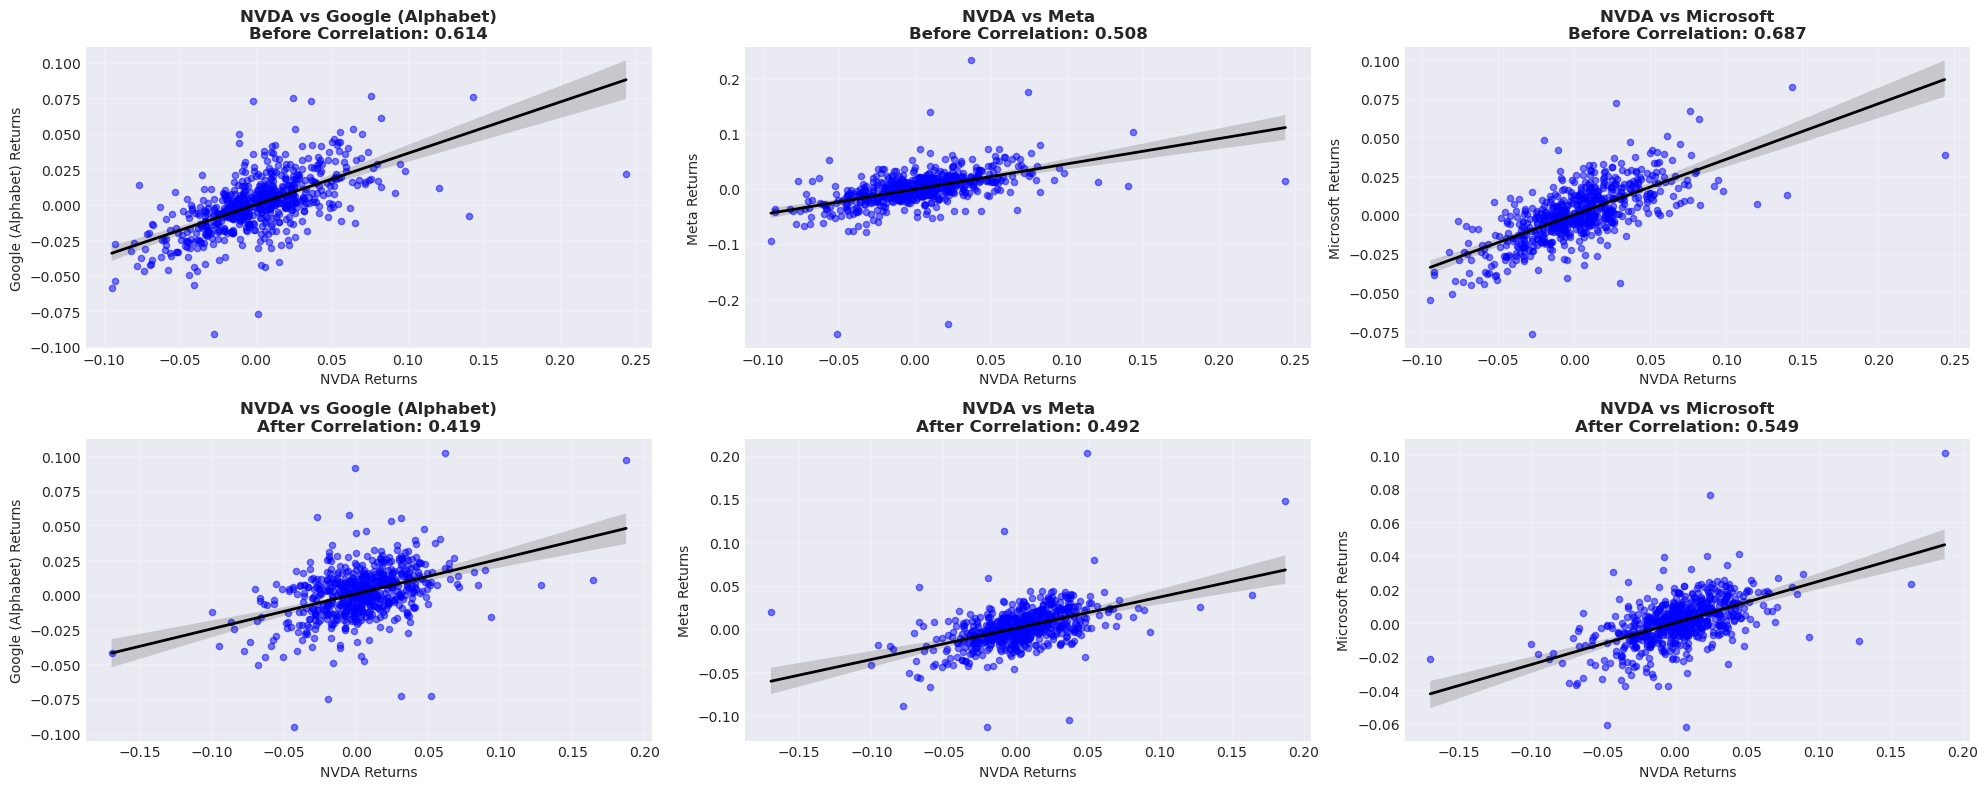

In [310]:
fig, axes = plt.subplots(2, 3, figsize=(20,8))

for idx, (ticker, ax) in enumerate(zip(['GOOGL', 'META', 'MSFT'], axes[0])):
    # Calculate correlation
    corr = nvda_corr_before[ticker]
    
    # Create scatter plot with regression line
    sns.regplot(x='NVDA', y=ticker, data=returns_before, ax=ax,
                scatter_kws={'alpha': 0.5, 's': 20, 'color': 'blue'},
                line_kws={'color': 'black', 'linewidth': 2})
    
    ax.set_title(f'NVDA vs {TICKERS[ticker]}\nBefore Correlation: {corr:.3f}', 
                 fontweight='bold')
    ax.set_xlabel('NVDA Returns')
    ax.set_ylabel(f'{TICKERS[ticker]} Returns')
    ax.grid(alpha=0.3)

for idx, (ticker, ax) in enumerate(zip(['GOOGL', 'META', 'MSFT'], axes[1])):
    # Calculate correlation
    corr = nvda_corr_after[ticker]
    
    # Create scatter plot with regression line
    sns.regplot(x='NVDA', y=ticker, data=returns_after, ax=ax,
                scatter_kws={'alpha': 0.5, 's': 20, 'color': 'blue'},
                line_kws={'color': 'black', 'linewidth': 2})
    
    ax.set_title(f'NVDA vs {TICKERS[ticker]}\nAfter Correlation: {corr:.3f}', 
                 fontweight='bold')
    ax.set_xlabel('NVDA Returns')
    ax.set_ylabel(f'{TICKERS[ticker]} Returns')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

From these visualizations, we can see that NVIDIA is indeed moderately correlated with various tech companies such as Google, Meta, and Microsoft. Next, we can directly compare the before and after correlations using a bar plot.

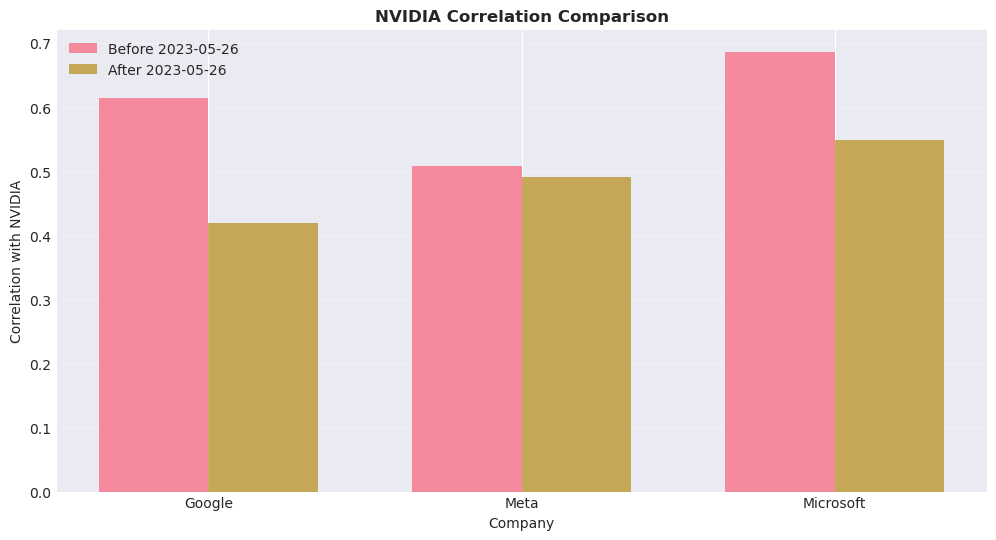

In [319]:
# 4. Bar chart comparing NVIDIA correlations
plt.figure(figsize=(12, 6))
x = np.arange(len(['GOOGL', 'META', 'MSFT']))
width = 0.35
companies = ['Google', 'Meta', 'Microsoft']
before_vals = [nvda_corr_before['GOOGL'], nvda_corr_before['META'], nvda_corr_before['MSFT']]
after_vals = [nvda_corr_after['GOOGL'], nvda_corr_after['META'], nvda_corr_after['MSFT']]

bars1 = plt.bar(x - width/2, before_vals, width, label=f'Before {SPLIT_DATE}', alpha=0.8)
bars2 = plt.bar(x + width/2, after_vals, width, label=f'After {SPLIT_DATE}', alpha=0.8)

plt.xlabel('Company')
plt.ylabel('Correlation with NVIDIA')
plt.title('NVIDIA Correlation Comparison', fontsize=12, fontweight='bold')
plt.legend()
plt.xticks(x, companies)
plt.grid(axis='y', alpha=0.3)
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

From this bar plot, it is clear that there was indeed a change in the correlation after NVIDIA's stock value turning point on May 26, 2023. After investors realized the demand of NVIDIA's GPU chips to feed the growth of gen AI, NVIDIA became more decoupled from the other major tech companies than it had been. This isn't to say that NVIDIA is less correlated to the success and hype surrounding AI; rather, that NVIDIA has become an independent driver of AI hype, cementing its role as a major company that dictates tech market conditions.


Lastly, we can use this analysis to see how Google, Meta, and Microsoft changed in correlation with respect to one another after NVIDIA's AI boom:

Text(0.5, 1.0, 'Change in Correlation (After - Before)')

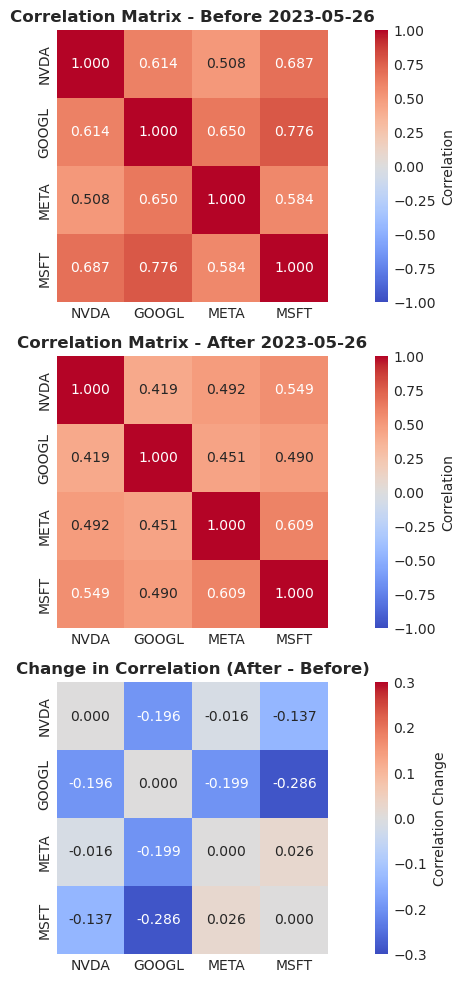

In [320]:
fig, axes = plt.subplots(3, figsize=(12,12))

# 1. Correlation Heatmaps
sns.heatmap(corr_before, ax=axes[0], annot=True, fmt='.3f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={'label': 'Correlation'})
axes[0].set_title(f'Correlation Matrix - Before {SPLIT_DATE}', fontsize=12, fontweight='bold')

sns.heatmap(corr_after, ax=axes[1], annot=True, fmt='.3f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, square=True, cbar_kws={'label': 'Correlation'})
axes[1].set_title(f'Correlation Matrix - After {SPLIT_DATE}', fontsize=12, fontweight='bold')

# 3. Correlation change heatmap
corr_change = corr_after - corr_before
sns.heatmap(corr_change, ax=axes[2], annot=True, fmt='.3f', cmap='coolwarm', center=0,
            vmin=-0.3, vmax=0.3, square=True, cbar_kws={'label': 'Correlation Change'})
axes[2].set_title('Change in Correlation (After - Before)', fontsize=12, fontweight='bold')

As you can see, compared to even NVIDIA, Google became more decoupled from all other tech companies. Remember also that this date represents NVIDIA's momentum-starting monthly earnings report in May 2023, so this is an interesting observation. To investigate why Google has become so decoupled, we will have to dive deep into Google's financial data, which I will leave for another time.